In [1]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator


![My Image](picture.jpeg)

# BB84 Protocol – General Idea

The BB84 protocol is a quantum key distribution (QKD) scheme that allows two parties
(Alice and Bob) to generate a shared secret key using quantum states.

---

## Step 1 – Key and Basis Generation (Alice)

1. Alice randomly generates a sequence of classical bits (0 and 1).
   → This will later become the secret key.

2. She then generates a second random sequence of 0 and 1,
   which defines the basis choice:

   0 → Z basis (Rectilinear basis)

   1 → X basis (Diagonal basis)


   Choosing a basis means choosing in which operator eigenbasis the qubit
   will be prepared.

   • Z basis corresponds to the eigenvectors of the Pauli Z operator:

$$
Z = \begin{pmatrix}1 & 0 \\ 0 & -1\end{pmatrix}
$$

   Eigenstates:
   $$|0\rangle =|H\rangle=
   \begin{pmatrix}1 \\ 0\end{pmatrix},
   \quad
   |1\rangle =|V\rangle=
   \begin{pmatrix}0 \\ 1\end{pmatrix}$$

   • X basis corresponds to the eigenvectors of the Pauli X operator:

   $$
   X =
   \begin{pmatrix}
   0 & 1 \\
   1 & 0
   \end{pmatrix}
   $$

   Eigenstates:
   $$
   |+\rangle =|D\rangle= \frac{1}{\sqrt{2}}
   \begin{pmatrix}1 \\ 1\end{pmatrix},
   \quad
   |-\rangle =|A\rangle= \frac{1}{\sqrt{2}}
   \begin{pmatrix}1 \\ -1\end{pmatrix}
   $$

   They are mutually unbiased bases: $$∣⟨H∣+⟩∣^2=0.5$$ So measuring in the wrong basis gives completely random results.

3. Alice encodes each classical bit as follows:

   • If basis = Z:
     - Bit 0 →  |0>
     - Bit 1 → |1>

   • If basis = X:
     - Bit 0 → |+>
     - Bit 1 → |->

   In circuit language:
   - |+> is obtained by applying Hadamard \(H\) to |0>
   - |-> is obtained by applying \(X\) then \(H\) to |0>

In a real experiment:
- The quantum states are photons.
- The basis corresponds to polarization of light.
- The photons are transmitted through an optical fiber (quantum channel).

---

## Step 2 – Measurement (Bob)

Bob independently generates his own random basis sequence (0 = Z, 1 = X).

Measuring in a basis means projecting the state onto the eigenvectors
of the corresponding operator.

• Measurement in Z basis:
  project onto {|0>, |1>}

• Measurement in X basis:
  project onto {|+>, |->}

  This can be implemented by applying \(H\) and then measuring in Z basis, since:

  $$
  H|+\rangle = |0\rangle
  \quad
  H|-\rangle = |1\rangle
  $$

Because quantum measurement depends on basis choice:

- If Bob chooses the same basis as Alice → deterministic result.
- If he chooses a different basis → 50/50 probability.

In [2]:
def create_full_circuit(sender_bits, sender_bases, receiver_bases): # bases (0=Z, 1=X)
    n_qubits = len(sender_bits)
    qc = QuantumCircuit(n_qubits, n_qubits)

    # Sender
    qc.barrier(label="Sender->")

    for i in range(n_qubits):
        if sender_bases[i] == 0:  # Z basis
            if sender_bits[i] == 1:
                qc.x(i) # |0> -> |1>
        else:  # X basis
            if sender_bits[i] == 0:
                qc.h(i) # |0> -> |+>
            else:
                qc.x(i)
                qc.h(i) # |0> -> |1> -> |->

    # Receiver
    qc.barrier(label="Receiver->")

    for i in range(n_qubits):
        if receiver_bases[i] == 1:  # X-basis measurement
            qc.h(i)
    qc.barrier()

    qc.measure(range(n_qubits), range(n_qubits))

    return qc



## Step 3 – Basis Comparison (Sifting)

After transmission, Alice and Bob communicate over a classical channel
(not quantum).

They publicly announce only their basis choices (NOT the bit values).

They discard all positions where their bases did not match.

The remaining bits form the **sifted key**.

In [3]:
def sifting(alice_bases, bob_bases, bits):
    key = []
    for a_basis, b_basis, bit in zip(alice_bases, bob_bases, bits):
        if a_basis == b_basis:
            key.append(int(bit))
    return key


def bitstring_to_bits(bitstring): # reverse bcs Qiskit returns bitstrings in reverse qubit order; output of the form [1,1,0,1,0]
    return [int(b) for b in bitstring[::-1]]

## Quantum Bit Error Rate (QBER)

If there is:
- no eavesdropping, then theoretically: $$QBER = 0$$

The Quantum Bit Error Rate is defined as:

$$
QBER =
\frac{\text{number of mismatched bits}}
{\text{total number of sifted bits}}
$$

It quantifies how much disturbance occurred in the transmission.

In real systems: They randomly choose, 5–10% of the raw key. They publicly reveal those bit values, compare them, compute the error rate.
After that: Those revealed bits are discarded permanently. They are NOT used in the final key.

In [4]:
def compute_qber(alice_key, bob_key):
    if len(alice_key) == 0:
        return 0
    errors = sum(a != b for a, b in zip(alice_key, bob_key))
    return errors / len(alice_key)




## Intercept–Resend Attack

In an intercept–resend attack:

1. Eve intercepts each photon.
2. She randomly chooses a measurement basis.
3. She measures the photon.
4. She resends a new photon to Bob based on her measurement result.

Since Eve does not know Alice’s basis:

- She sometimes measures in the wrong basis.
- This disturbs the quantum state.
- Bob receives incorrect results even when his basis matches Alice’s.

Therefore:

$$ QBER > 0 $$

Alice and Bob can detect an eavesdropper by estimating QBER.

If QBER exceeds a security threshold, the protocol is aborted.

![My Image](intersept_resend%20attack.png)

In [5]:
def bb84_protocol(n_bits=8, seed=0, attack=False):
    np.random.seed(seed)
    backend = AerSimulator(seed_simulator=seed)

    alice_bits = np.random.randint(2, size=n_bits)
    alice_bases = np.random.randint(2, size=n_bits)
    bob_bases = np.random.randint(2, size=n_bits)

    alice_to_eve_circuit = None
    eve_to_bob_circuit = None
    eve_bases = None
    eve_bits = None

    if attack:
        # Eve chooses bases
        eve_bases = np.random.randint(2, size=n_bits)

        # Alice -> Eve circuit
        alice_to_eve_circuit = create_full_circuit(
            alice_bits, alice_bases, eve_bases
        )

        # Simulate Eve measurement
        transpiled_eve = transpile(alice_to_eve_circuit, backend)
        job_eve = backend.run(transpiled_eve, shots=1)
        result_eve = job_eve.result()
        eve_counts = result_eve.get_counts()
        eve_bitstring = list(eve_counts.keys())[0]
        eve_bits = bitstring_to_bits(eve_bitstring)

        # Eve -> Bob circuit
        eve_to_bob_circuit = create_full_circuit(
            eve_bits, eve_bases, bob_bases
        )

        full_circuit = eve_to_bob_circuit

    else:
        full_circuit = create_full_circuit(
            alice_bits, alice_bases, bob_bases
        )

    # Bob measurement
    transpiled = transpile(full_circuit, backend)
    job = backend.run(transpiled, shots=1)
    result = job.result()

    counts = result.get_counts()
    bitstring = list(counts.keys())[0] # from {'01011': 1} gives ['01011'];  list(counts.keys())[0] where [0] bcs shots=1
    bob_measured_bits = bitstring_to_bits(bitstring) # reverse ['01011'] to [1,1,0,1,0]

    # Sifting
    alice_key = sifting(alice_bases, bob_bases, alice_bits)
    bob_key = sifting(alice_bases, bob_bases, bob_measured_bits)

    qber = compute_qber(alice_key, bob_key)

    return {
        'alice_bits': alice_bits.tolist(),
        'alice_bases': alice_bases.tolist(),
        'bob_bases': bob_bases.tolist(),
        'bob_results': bob_measured_bits,
        'alice_key': alice_key,
        'bob_key': bob_key,
        'qber': qber,
        'alice_to_eve_circuit': alice_to_eve_circuit,
        'eve_to_bob_circuit': eve_to_bob_circuit,
        'full_circuit': full_circuit,
        'eve_bases': None if eve_bases is None else eve_bases.tolist(),
        'eve_results': eve_bits
    }


Alice bits:    [0, 0, 1, 1, 0]
Alice bases:   [0, 0, 1, 1, 1]
Eve bases:     None
Eve results:   None
Bob bases:     [0, 1, 1, 1, 0]
Bob results:   [0, 0, 1, 1, 1]
Alice key:     [0, 1, 1]
Bob key:       [0, 1, 1]
QBER:          0.0

 Alice → Bob Circuit 


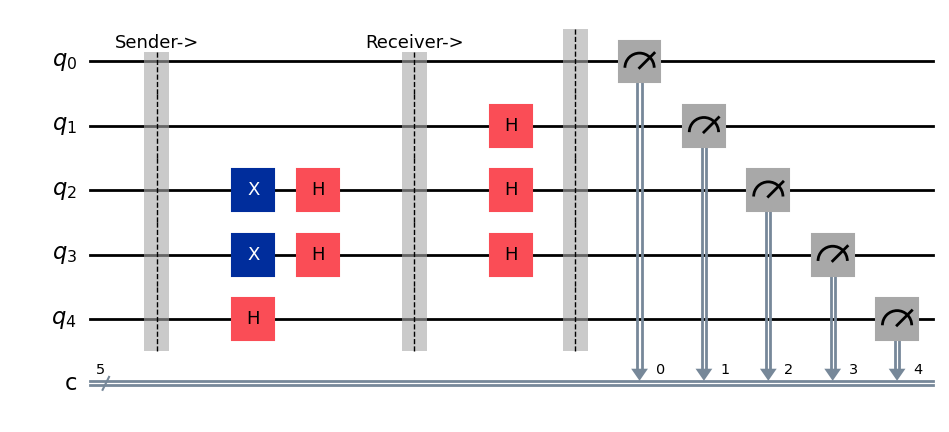

In [6]:
results = bb84_protocol(n_bits=5, seed=3, attack=False)

print("Alice bits:   ", results['alice_bits'])
print("Alice bases:  ", results['alice_bases'])
print("Eve bases:    ", results['eve_bases'])
print("Eve results:  ", results['eve_results'])
print("Bob bases:    ", results['bob_bases'])
print("Bob results:  ", results['bob_results'])
print("Alice key:    ", results['alice_key'])
print("Bob key:      ", results['bob_key'])
print("QBER:         ", results['qber'])

if results['alice_to_eve_circuit'] is not None:
    print("\n Alice → Eve Circuit")
    display(results['alice_to_eve_circuit'].draw('mpl'))

if results['eve_to_bob_circuit'] is not None:
    print("\n Eve → Bob Circuit")
    display(results['eve_to_bob_circuit'].draw('mpl'))

if results['alice_to_eve_circuit'] is None:
    print("\n Alice → Bob Circuit ")
    display(results['full_circuit'].draw('mpl'))


Alice bits:    [0, 0, 1, 1, 0]
Alice bases:   [0, 0, 1, 1, 1]
Eve bases:     [1, 1, 0, 0, 0]
Eve results:   [1, 0, 0, 0, 1]
Bob bases:     [0, 1, 1, 1, 0]
Bob results:   [0, 0, 0, 1, 1]
Alice key:     [0, 1, 1]
Bob key:       [0, 0, 1]
QBER:          0.3333333333333333

 Alice → Eve Circuit


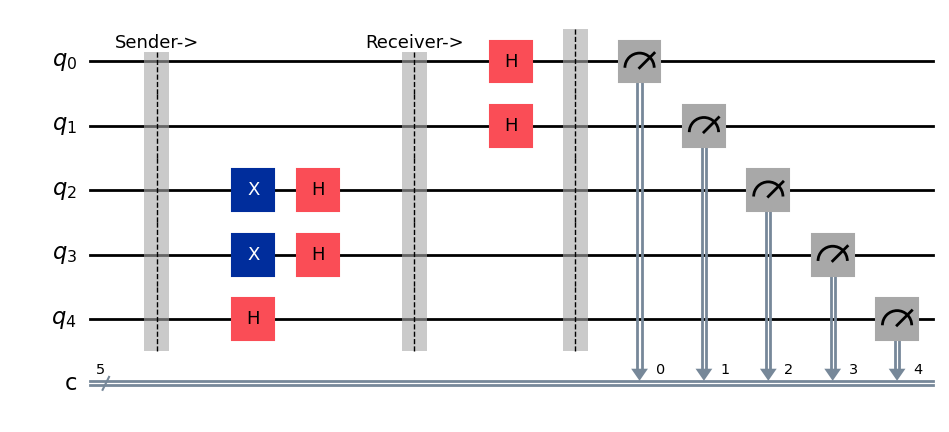


 Eve → Bob Circuit


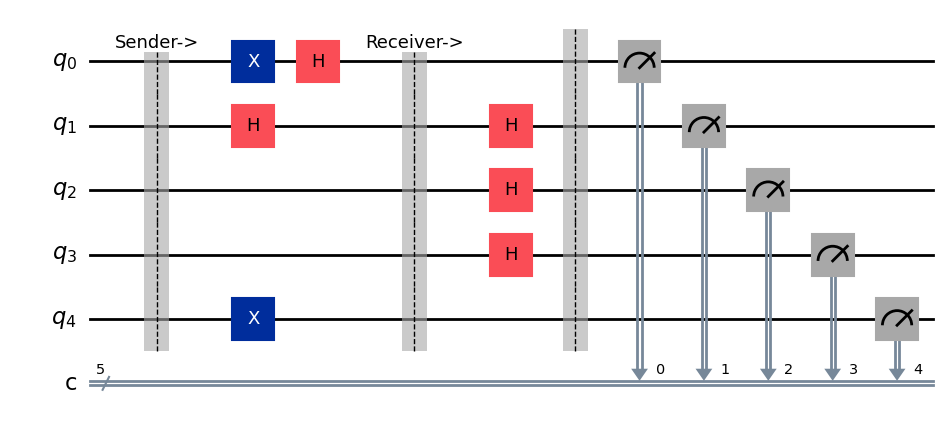

In [7]:
results = bb84_protocol(n_bits=5, seed=3, attack=True)

print("Alice bits:   ", results['alice_bits'])
print("Alice bases:  ", results['alice_bases'])
print("Eve bases:    ", results['eve_bases'])
print("Eve results:  ", results['eve_results'])
print("Bob bases:    ", results['bob_bases'])
print("Bob results:  ", results['bob_results'])
print("Alice key:    ", results['alice_key'])
print("Bob key:      ", results['bob_key'])
print("QBER:         ", results['qber'])

if results['alice_to_eve_circuit'] is not None:
    print("\n Alice → Eve Circuit")
    display(results['alice_to_eve_circuit'].draw('mpl'))

if results['eve_to_bob_circuit'] is not None:
    print("\n Eve → Bob Circuit")
    display(results['eve_to_bob_circuit'].draw('mpl'))

if results['alice_to_eve_circuit'] is None:
    print("\n Alice → Bob Circuit ")
    display(results['full_circuit'].draw('mpl'))
